# Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)


import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix
from skorch import NeuralNetClassifier
from skorch.helper import predefined_split
from skorch.callbacks import EpochScoring
from IPython.display import display
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

SAVE_DIR = "learning_curves"
os.makedirs(SAVE_DIR, exist_ok=True)

from sklearn.model_selection import cross_val_score, StratifiedKFold

NumPy: 2.5.1
Pandas: 3.0.5
Device: cpu


# Load Dataset

In [2]:
data = pd.read_csv(
    "gsar_a_2521295_sm1572.csv",
    sep=";",
    skiprows=1,
    encoding="utf-8-sig"
)

data = data.dropna(subset=["SMILES", "label"]).reset_index(drop=True)
data["label"] = data["label"].astype(int)

print(data.shape)
data[["compound ID", "SMILES", "label"]].head()

(846, 8)


,compound ID,SMILES,label
0,A001,FC1(F)CN(c2c(C(F)(F)F)cnc3[nH]c(C4=CCNC4)cc23)C1,1
1,A002,CC(C)[C@@H](NC(=O)c1cc(-c2cnn3cc(-c4ccc(OCCN5C...,1
2,A003,O=C(NCC(F)(F)F)c1cc(-c2cnc3[nH]c(C4=CCCNC4)cc3...,1
3,A004,CN1CC=C(c2cc3cc(-c4csc(C(=O)NCC(F)(F)F)c4)cnc3...,1
4,A005,O=C(NCC(F)(F)F)c1cc(-c2cnc3[nH]c(C4=CCNCC4)cc3...,1


# Tokenisasi SMILES


In [3]:
X_smiles = data["SMILES"].values

charset = set("".join(list(X_smiles)) + "!E")
char_to_int = dict((c, i) for i, c in enumerate(charset))
int_to_char = dict((i, c) for i, c in enumerate(charset))

embed = max([len(smile) for smile in X_smiles]) + 5
vocab_size = len(charset)

print("Jumlah karakter unik (vocab_size):", vocab_size)
print("Panjang embedding (embed):", embed)
print(str(charset))

Jumlah karakter unik (vocab_size): 34
Panjang embedding (embed): 102
{']', '\\', 'B', 'n', '2', '3', 's', 'r', 'F', '@', 'c', 'P', '=', '-', '[', 'o', '(', 'N', 'S', '5', 'l', 'E', 'H', ')', '#', 'O', '4', '+', '/', '!', 'C', '1', 'I', '6'}


In [4]:
char_to_int

{']': 0,
 '\\': 1,
 'B': 2,
 'n': 3,
 '2': 4,
 '3': 5,
 's': 6,
 'r': 7,
 'F': 8,
 '@': 9,
 'c': 10,
 'P': 11,
 '=': 12,
 '-': 13,
 '[': 14,
 'o': 15,
 '(': 16,
 'N': 17,
 'S': 18,
 '5': 19,
 'l': 20,
 'E': 21,
 'H': 22,
 ')': 23,
 '#': 24,
 'O': 25,
 '4': 26,
 '+': 27,
 '/': 28,
 '!': 29,
 'C': 30,
 '1': 31,
 'I': 32,
 '6': 33}

# Fungsi Vectorize

In [5]:
def vectorize(smiles, charset, char_to_int, embed):
    one_hot = np.zeros((smiles.shape[0], embed, len(charset)), dtype=np.int8)
    for i, smile in enumerate(smiles):
        one_hot[i, 0, char_to_int["!"]] = 1
        for j, c in enumerate(smile):
            if c in char_to_int:
                one_hot[i, j + 1, char_to_int[c]] = 1
        one_hot[i, len(smile) + 1:, char_to_int["E"]] = 1
    return one_hot[:, 0:-1, :]

X_onehot = vectorize(X_smiles, charset, char_to_int, embed)
X_encoded = np.argmax(X_onehot, axis=2)

# Visual Hasil Encoding SMILES

In [6]:
print("vocab_size:", vocab_size, "| embed:", embed)
print("X_onehot shape :", X_onehot.shape)
print("X_encoded shape:", X_encoded.shape)

idx = 0

print("\nSMILES asli:", X_smiles[idx])
print()
print("One-hot encoding, 10 posisi pertama:")
print(X_onehot[idx][:10])

print("Integer-encoded, 20 posisi pertama:")
print(X_encoded[idx][:20])

decoded = "".join([int_to_char[i] for i in X_encoded[idx]])
print("Hasil decode balik:", decoded)

vocab_size: 34 | embed: 102
X_onehot shape : (846, 101, 34)
X_encoded shape: (846, 101)

SMILES asli: FC1(F)CN(c2c(C(F)(F)F)cnc3[nH]c(C4=CCNC4)cc23)C1

One-hot encoding, 10 posisi pertama:
[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]
Integer-encoded, 20 posisi pertama:
[29  8 30 31 16  8 23 30 17 16 10  4 10 16 30 16  8 23 16  8]
Ha

# Penggabungan Hasil Encoding SMILES dengan Label

In [7]:
y = data["label"].values

print("X_encoded shape:", X_encoded.shape)
print("y shape         :", y.shape)

assert X_encoded.shape[0] == y.shape[0], "Jumlah baris SMILES dan label tidak sinkron!"

X_encoded shape: (846, 101)
y shape         : (846,)


# Split Train/Test

In [8]:
X = X_encoded
y_arr = y.reshape(-1, 1) if y.ndim == 1 else y

X_train, X_test, Y_train, Y_test = train_test_split(
    X, y_arr,
    test_size=0.3,
    random_state=42,
    stratify=y_arr
)

print("Training pool (untuk CV):", X_train.shape)
print("Holdout test (dikunci)  :", X_test.shape)

Training pool (untuk CV): (592, 101)
Holdout test (dikunci)  : (254, 101)


# Siapkan Data untuk Cross-Validation

In [9]:
X_cv = X_train.astype(np.int64)
Y_cv = Y_train.flatten().astype(np.int64) if Y_train.ndim > 1 else Y_train.astype(np.int64)

X_test_int = X_test.astype(np.int64)
Y_test_int = Y_test.flatten().astype(np.int64) if Y_test.ndim > 1 else Y_test.astype(np.int64)

print("Data untuk Cross-Validation:", X_cv.shape)
print("Holdout Test (dikunci)     :", X_test_int.shape)

Data untuk Cross-Validation: (592, 101)
Holdout Test (dikunci)     : (254, 101)


# Pembentukan model Baseline

In [10]:
class LSTMBaselineSkorch(nn.Module):
    def __init__(self, vocab_size, embedding_dim=50, units_list=[64]):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm_layers = nn.ModuleList()
        input_size = embedding_dim
        for units in units_list:
            self.lstm_layers.append(nn.LSTM(input_size=input_size, hidden_size=units, batch_first=True))
            input_size = units
        self.output_layer = nn.Linear(units_list[-1], 2)

    def forward(self, x):
        out = self.embedding(x)
        for lstm in self.lstm_layers:
            out, _ = lstm(out)
        out = out[:, -1, :]
        return self.output_layer(out)


def build_skorch_net_with_history(units_list, X_val, Y_val, vocab_size, embedding_dim=50,
                                   epochs=50, lr=0.001, batch_size=32, device=device):
    val_dataset = TensorDataset(
        torch.tensor(X_val, dtype=torch.long),
        torch.tensor(Y_val, dtype=torch.long)
    )

    return NeuralNetClassifier(
        module=LSTMBaselineSkorch,
        module__vocab_size=vocab_size,
        module__embedding_dim=embedding_dim,
        module__units_list=units_list,
        max_epochs=epochs,
        lr=lr,
        optimizer=torch.optim.Adam,
        criterion=nn.CrossEntropyLoss,
        batch_size=batch_size,
        device=device,
        train_split=predefined_split(val_dataset),
        callbacks=[
            ("train_acc", EpochScoring(scoring="accuracy", on_train=True, name="train_acc", lower_is_better=False)),
        ],
        verbose=0
    )


def compute_confusion_matrix(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    return TP, TN, FP, FN


def plot_confusion_matrix_image(TP, TN, FP, FN, model_name="", dataset_name=""):
    cm = np.array([[TP, FN],
                   [FP, TN]])

    fig, ax = plt.subplots(figsize=(5, 4.5))
    im = ax.imshow(cm, cmap="Blues")

    labels = ["Aktif (1)", "Inaktif (0)"]
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_xlabel("Kelas Prediksi")
    ax.set_ylabel("Kelas Aktual")
    ax.set_title(f"Confusion Matrix - {model_name} ({dataset_name})")

    thresh = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], "d"),
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black",
                     fontsize=14, fontweight="bold")

    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()


def plot_avg_learning_curve(histories, model_name, save_dir=SAVE_DIR):
    avg_train_loss = np.mean([h["loss"] for h in histories], axis=0)
    avg_val_loss   = np.mean([h["val_loss"] for h in histories], axis=0)
    avg_train_acc  = np.mean([h["accuracy"] for h in histories], axis=0)
    avg_val_acc    = np.mean([h["val_accuracy"] for h in histories], axis=0)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(avg_train_loss, label="Training Loss")
    axes[0].plot(avg_val_loss, label="Validation Loss")
    axes[0].set_title(f"Loss Curve - {model_name}")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(avg_train_acc, label="Training Accuracy")
    axes[1].plot(avg_val_acc, label="Validation Accuracy")
    axes[1].set_title(f"Accuracy Curve - {model_name}")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    save_path = os.path.join(save_dir, f"learning_curve_CV_{model_name.replace(' ', '_')}.png")
    plt.savefig(save_path, dpi=150)
    print(f"Learning curve disimpan di: {save_path}")
    plt.show()

# Konfigurasi Baseline

In [11]:
baseline_configs = {
    "Baseline 1": [64],
    "Baseline 2": [64, 128],
    "Baseline 3": [64, 128, 256],
}

config_table = []

for name, units_list in baseline_configs.items():
    config_table.append({
        "Konfigurasi": name,
        "Jumlah Layer LSTM": len(units_list),
        "Node per Lapisan": str(tuple(units_list)),
        "Lapisan Output": "Dense 1 neuron, aktivasi Sigmoid",
        "Learning Rate": 0.001,
        "Batch Size": 32,
        "Optimizer": "Adam",
        "Epoch": 50,
    })

config_df = pd.DataFrame(config_table).set_index("Konfigurasi")
display(config_df)

,Jumlah Layer LSTM,Node per Lapisan,Lapisan Output,Learning Rate,Batch Size,Optimizer,Epoch
Konfigurasi,,,,,,,
Baseline 1,1,"(64,)","Dense 1 neuron, aktivasi Sigmoid",0.001,32,Adam,50
Baseline 2,2,"(64, 128)","Dense 1 neuron, aktivasi Sigmoid",0.001,32,Adam,50
Baseline 3,3,"(64, 128, 256)","Dense 1 neuron, aktivasi Sigmoid",0.001,32,Adam,50


# Cross-Validation (cv=5) dengan Learning Curve per Fold

In [12]:
def cross_val_with_history(units_list, X_cv, Y_cv, k=5, epochs=50, lr=0.001, batch_size=32, model_name=""):
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

    fold_scores = []
    fold_histories = []

    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_cv, Y_cv)):
        print(f"--- {model_name} | Fold {fold_idx + 1}/{k} ---")

        X_tr, X_val = X_cv[train_idx], X_cv[val_idx]
        Y_tr, Y_val = Y_cv[train_idx], Y_cv[val_idx]

        net = build_skorch_net_with_history(
            units_list, X_val, Y_val,
            vocab_size=vocab_size, epochs=epochs, lr=lr, batch_size=batch_size
        )
        net.fit(X_tr, Y_tr)

        history = {
            "loss": [row["train_loss"] for row in net.history],
            "val_loss": [row["valid_loss"] for row in net.history],
            "accuracy": [row["train_acc"] for row in net.history],
            "val_accuracy": [row["valid_acc"] for row in net.history],
        }
        fold_histories.append(history)

        val_acc = history["val_accuracy"][-1]
        fold_scores.append(val_acc)
        print(f"Fold {fold_idx + 1} val_accuracy: {val_acc:.4f}")

    return np.array(fold_scores), fold_histories

# Jalankan Cross Val

In [13]:
cv_results = {}
cv_histories = {}

for name, units_list in baseline_configs.items():
    print("="*60)
    print(f"CROSS-VALIDATION (cv=5) | {name} | LSTM layers: {units_list}")
    print("="*60)

    scores, histories = cross_val_with_history(
        units_list, X_cv, Y_cv,
        k=5, epochs=50, lr=0.001, batch_size=32, model_name=name
    )
    cv_results[name] = scores
    cv_histories[name] = histories

    print(f"Rata-rata Accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})")

CROSS-VALIDATION (cv=5) | Baseline 1 | LSTM layers: [64]
--- Baseline 1 | Fold 1/5 ---
Fold 1 val_accuracy: 0.8319
--- Baseline 1 | Fold 2/5 ---
Fold 2 val_accuracy: 0.8824
--- Baseline 1 | Fold 3/5 ---
Fold 3 val_accuracy: 0.8729
--- Baseline 1 | Fold 4/5 ---
Fold 4 val_accuracy: 0.8305
--- Baseline 1 | Fold 5/5 ---
Fold 5 val_accuracy: 0.8729
Rata-rata Accuracy: 0.8581 (+/- 0.0222)
CROSS-VALIDATION (cv=5) | Baseline 2 | LSTM layers: [64, 128]
--- Baseline 2 | Fold 1/5 ---
Fold 1 val_accuracy: 0.8151
--- Baseline 2 | Fold 2/5 ---
Fold 2 val_accuracy: 0.8908
--- Baseline 2 | Fold 3/5 ---
Fold 3 val_accuracy: 0.8814
--- Baseline 2 | Fold 4/5 ---
Fold 4 val_accuracy: 0.8390
--- Baseline 2 | Fold 5/5 ---
Fold 5 val_accuracy: 0.8644
Rata-rata Accuracy: 0.8581 (+/- 0.0278)
CROSS-VALIDATION (cv=5) | Baseline 3 | LSTM layers: [64, 128, 256]
--- Baseline 3 | Fold 1/5 ---
Fold 1 val_accuracy: 0.8824
--- Baseline 3 | Fold 2/5 ---
Fold 2 val_accuracy: 0.8824
--- Baseline 3 | Fold 3/5 ---
Fold 3 v

# Learning Curve

Learning curve disimpan di: learning_curves\learning_curve_CV_Baseline_1.png


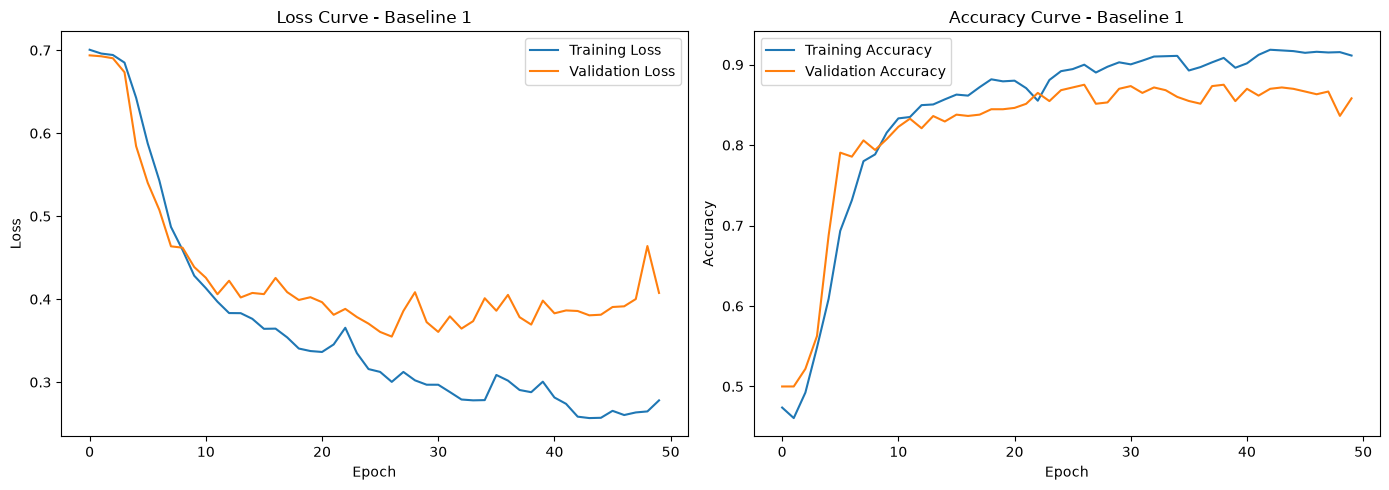

Learning curve disimpan di: learning_curves\learning_curve_CV_Baseline_2.png


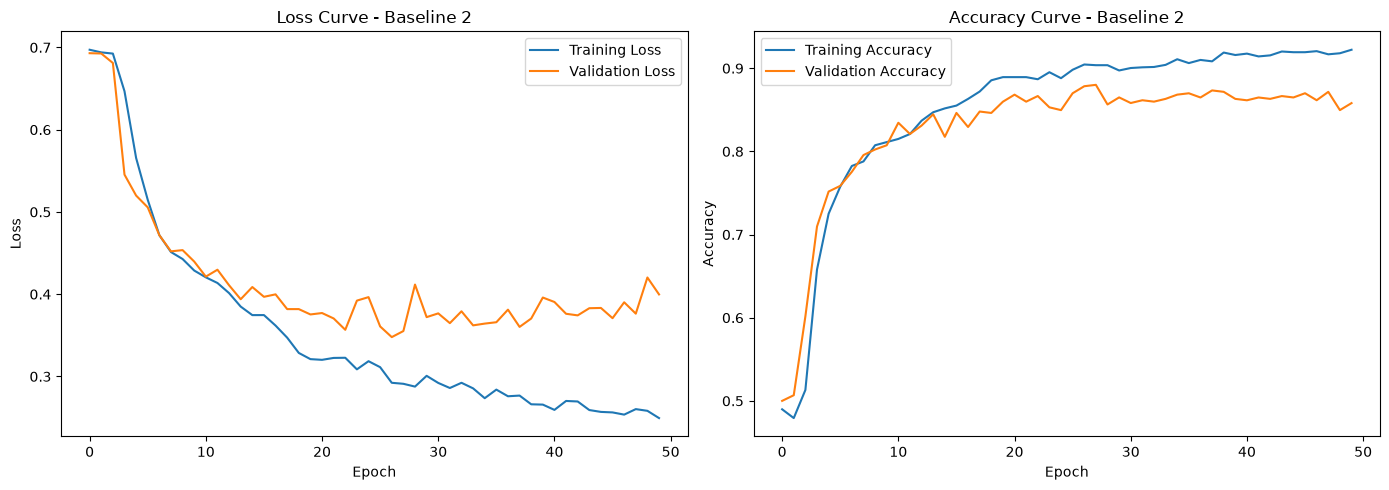

Learning curve disimpan di: learning_curves\learning_curve_CV_Baseline_3.png


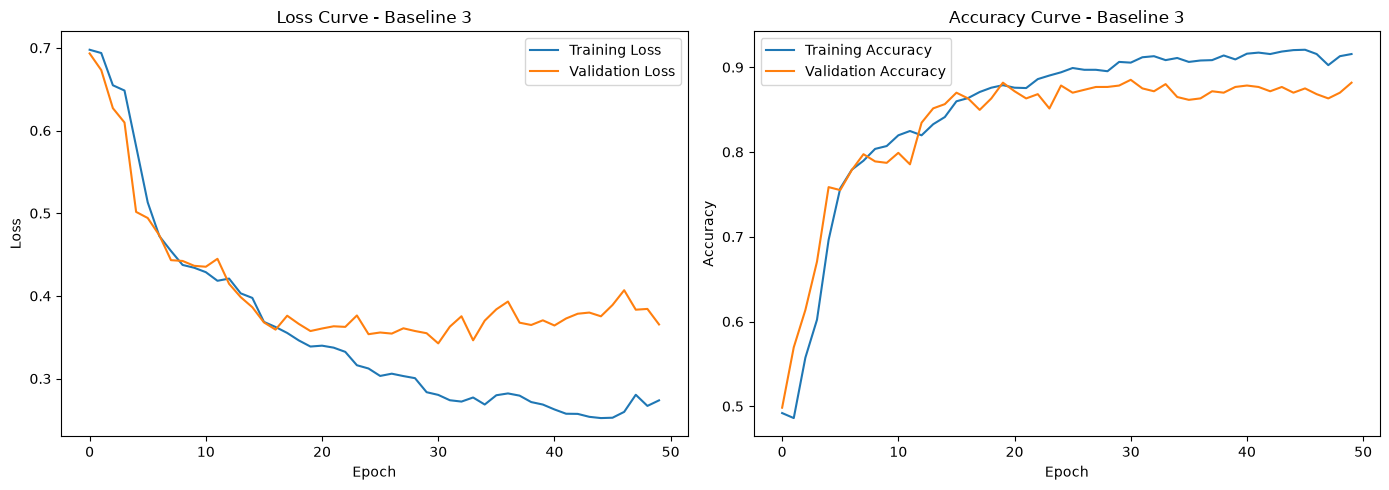

In [14]:
for name, histories in cv_histories.items():
    plot_avg_learning_curve(histories, model_name=name)

# Ringkasan Hasil Cross-Validation ke Satu DataFrame

In [15]:
summary_rows = []

for name, units_list in baseline_configs.items():
    scores = cv_results[name]          # array accuracy tiap fold (5 nilai)
    histories = cv_histories[name]      # list of dict, satu per fold

    # Rata-rata learning curve dari 5 fold, ambil nilai epoch TERAKHIR
    avg_train_loss = np.mean([h["loss"][-1] for h in histories])
    avg_val_loss   = np.mean([h["val_loss"][-1] for h in histories])
    avg_train_acc  = np.mean([h["accuracy"][-1] for h in histories])
    avg_val_acc    = np.mean([h["val_accuracy"][-1] for h in histories])

    row = {
        "Konfigurasi": name,
        "Jumlah Layer LSTM": len(units_list),
        "Node per Lapisan": str(tuple(units_list)),
        "Learning Rate": 0.001,
        "Batch Size": 32,
        "Epoch": 50,
    }

    # Accuracy tiap fold (Fold 1 - Fold 5)
    for i, score in enumerate(scores):
        row[f"Fold {i+1} Accuracy"] = score

    row["Accuracy Mean"] = scores.mean()
    row["Accuracy Std"]  = scores.std()

    # Nilai akhir learning curve (rata-rata dari 5 fold, epoch terakhir)
    row["Avg Train Loss (epoch akhir)"] = avg_train_loss
    row["Avg Val Loss (epoch akhir)"]   = avg_val_loss
    row["Avg Train Acc (epoch akhir)"]  = avg_train_acc
    row["Avg Val Acc (epoch akhir)"]    = avg_val_acc

    summary_rows.append(row)

full_summary_df = pd.DataFrame(summary_rows).set_index("Konfigurasi")
display(full_summary_df)

,Jumlah Layer LSTM,Node per Lapisan,Learning Rate,Batch Size,Epoch,Fold 1 Accuracy,Fold 2 Accuracy,Fold 3 Accuracy,Fold 4 Accuracy,Fold 5 Accuracy,Accuracy Mean,Accuracy Std,Avg Train Loss (epoch akhir),Avg Val Loss (epoch akhir),Avg Train Acc (epoch akhir),Avg Val Acc (epoch akhir)
Konfigurasi,,,,,,,,,,,,,,,,
Baseline 1,1,"(64,)",0.001,32,50,0.831933,0.882353,0.872881,0.830508,0.872881,0.858111,0.022231,0.278059,0.407524,0.911307,0.858111
Baseline 2,2,"(64, 128)",0.001,32,50,0.815126,0.890756,0.881356,0.838983,0.864407,0.858126,0.027782,0.249384,0.399737,0.922294,0.858126
Baseline 3,3,"(64, 128, 256)",0.001,32,50,0.882353,0.882353,0.923729,0.847458,0.872881,0.881755,0.024567,0.273697,0.365495,0.915548,0.881755
